<a href="https://colab.research.google.com/github/BenCheung1/Pytorch_Sandbox/blob/main/Pyt_ConvolutionalNN_MNIST_Pt4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# CONVOLUTIONAL NEURAL NETWORK
# Import Neural Network
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

# Importing torchvision - datasets
# Convert MNIST Image Files into a Tensor of 4-Dimensions
# (# of images, Heights, Width, Color Channel)
transform = transforms.ToTensor()

# torchvisions - datasets has various image datasets.
# see https://www.tensorflow.org/datasets/catalog/mnist
# datasets.MNIST indicates to get the MNIST numbers image set.
# Train Data, MNIST from datasets
train_data = datasets.MNIST(root='/cnn_data', train=True, download =True, transform=transform)



In [16]:
# Test Data, already downloaded MNIST Data
# Train = False, This is test Data not Train data.
test_data = datasets.MNIST(root='/cnn_data', train=False, download =True, transform=transform)
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [17]:
# Create a batch size for images, e.g. 10
train_loader = DataLoader(train_data, batch_size=10, shuffle= True)
test_loader = DataLoader(test_data, batch_size=10, shuffle= False)
# Define our CNN Model
# Describe convolutional layer and what it's doint
# two convolutional layers
# Conv2d: Input size #images=1, # filters outputs feature maps=6,
#         Kernel size=3 3x3, Stride length=1 one@time.
conv1 = nn.Conv2d(1, 6, 3, 1)
conv2 = nn.Conv2d(6, 16, 3, 1)
# Grab 1 MNIST record.
for i, (X_Train, y_train) in enumerate(train_data):
  break

In [18]:
# One image, size of the image is 28x28 pixels
X_Train.shape
# OUTPUT: torch.Size ([1, 28, 28])

torch.Size([1, 28, 28])

In [19]:
# Change this to 4-dimensions
x = X_Train.view(1,1,28,28)
# Perform first convolution
# Rectified Linear Unit for Activation Function
x = F.relu(conv1(x))
x.shape
# OUTPUT: torch.Size([1,6,26,26])
# 1 is the # of images, 6 is the # of filters feature maps
# 26x26 is the image.

torch.Size([1, 6, 26, 26])

In [20]:
# Pass Through the Pooling Layer
x = F.max_pool2d(x,2,2)
# Kernal of 2 & Stride of 2.
x.shape
# Pooling a 26x26 down to 13x13 b/c of 2x2 Kernel w/ Stride of 2. 26/2=13

torch.Size([1, 6, 13, 13])

In [21]:
# Do the second convolutional layer
x = F.relu(conv2(x))

In [22]:
x.shape
# didn't set Padding, so lose 2 pixels around the outside.
# Pooling Layer
x = F.max_pool2d(x,2,2)

In [23]:
x.shape
# will become OUTPUT torch.Size 1,16,5,5 because 11/2 =5
# this rounds down because you can't invent data to round up
# at this point, a Conv-Layer1 > Pooling > Cov-Layer2 > Pooling > output

torch.Size([1, 16, 5, 5])

In [24]:
# Model Class
class ConvolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1,6,3,1) #input, output, kernel, stride
    self.conv2 = nn.Conv2d(6,16,3,1)
    # Fully Connected Layers
    self.fc1 = nn.Linear(5*5*16, 120)
    # after 2 Convo layers > 5x5. 120 Neurons
    self.fc2 = nn.Linear(120, 84)
    # Each Fully Connected Layer reduces # of neurons
    self.fc3 = nn.Linear(84, 10) # input, output
    # Forward Function
  def forward(self,X):
    X = F.relu(self.conv1(X))
    X = F.max_pool2d(X,2,2) # 2x2 kernal and stride 2
    # Second Pass
    X = F.relu(self.conv2(X))
    X = F.max_pool2d(X,2,2) # 2x2 kernal and stride 2
    # Flatten, Re-view to Flatten
    X = X.view (-1,16*5*5) # negative one vary the batch size.

    # Fully Connected Layers
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.fc3(X)
    return F.log_softmax(X, dim=1)

In [25]:
# Create an instance of the Model
torch.manual_seed(87)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [26]:
# Loss Function Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Smaller the learning the rate, longer it will take to train


In [27]:
import time
start_time = time.time()

# Create Variables to Track Things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# For Loop of Epochs
for i in range(epochs):
  trn_corr = 0
  tst_corr = 0

  # Train
  for b,(X_train, y_train) in enumerate (train_loader):
    b+=1 # start our batches at 1
    y_pred = model (X_train) # get predicted values from training not flattened.
    loss = criterion (y_pred, y_train) # how off are we?
    # compare the predictions to correction answers in Y_train
    predicted = torch.max(y_pred.data, 1)[1]
    # add up the number of correct predictions.
    batch_corr = (predicted == y_train).sum() # how many corrects from this batch
    # true = 1, false =0.
    trn_corr += batch_corr # keep track as we go along in training.
    # Update our parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Print out results
    if b%600 == 0:
      print (f'Epoch: {i} Batch: {b} Loss: {loss.item()}')
    train_losses.append(loss)
    train_correct.append(trn_corr)

  # Test
  with torch.no_grad(): #No gradient so don't update weights biases w/ test data
    for b,(X_test,y_test) in enumerate(test_loader):
      y_val = model(X_test)
      predicted = torch.max (y_val.data, 1)[1] # add up correct predictions
      tst_corr += (predicted == y_test).sum() # T=1, F=0 sum
  loss=criterion(y_val, y_test)
  test_losses.append (loss)
  test_correct.append(tst_corr)

current_time = time.time()
total = current_time - start_time
print(f'Training Took: {total/60} time')

Epoch: 0 Batch: 600 Loss: 0.466907262802124
Epoch: 0 Batch: 1200 Loss: 0.020069371908903122
Epoch: 0 Batch: 1800 Loss: 0.5469075441360474
Epoch: 0 Batch: 2400 Loss: 0.25480183959007263
Epoch: 0 Batch: 3000 Loss: 0.017892630770802498
Epoch: 0 Batch: 3600 Loss: 0.0013806248316541314
Epoch: 0 Batch: 4200 Loss: 0.05105609446763992
Epoch: 0 Batch: 4800 Loss: 0.04925256222486496
Epoch: 0 Batch: 5400 Loss: 0.20937970280647278
Epoch: 0 Batch: 6000 Loss: 0.02696751058101654
Epoch: 1 Batch: 600 Loss: 0.015714559704065323
Epoch: 1 Batch: 1200 Loss: 0.021620821207761765
Epoch: 1 Batch: 1800 Loss: 0.21632714569568634
Epoch: 1 Batch: 2400 Loss: 0.029335061088204384
Epoch: 1 Batch: 3000 Loss: 0.003946410957723856
Epoch: 1 Batch: 3600 Loss: 0.1070999875664711
Epoch: 1 Batch: 4200 Loss: 0.0003747585287783295
Epoch: 1 Batch: 4800 Loss: 0.10575605928897858
Epoch: 1 Batch: 5400 Loss: 0.013564574532210827
Epoch: 1 Batch: 6000 Loss: 0.0012995662400498986
Epoch: 2 Batch: 600 Loss: 0.16047576069831848
Epoch: 

In [33]:
# Graph the Loss at Epoch
train_losses = [tl.item() for tl in train_losses]
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Validation Loss")
plt.title ("Loss at Epoch")
plt.legend()

AttributeError: 'float' object has no attribute 'item'

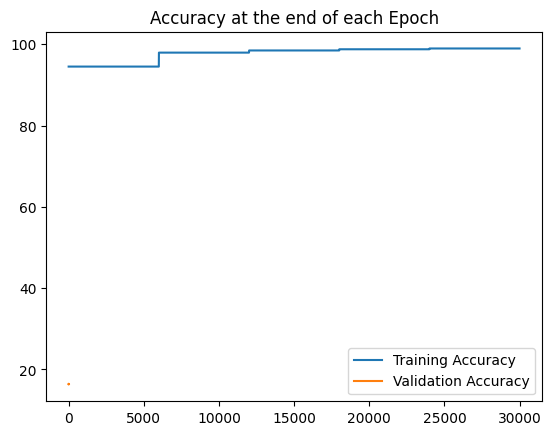

In [31]:
# Graph the Accuracy at the end of Each Epoch
plt.plot([t/600 for t in train_correct], label="Training Accuracy")
plt.plot([t/600 for t in test_correct], label="Validation Accuracy")
plt.title("Accuracy at the end of each Epoch")
plt.legend()

In [1]:
# graph the accuracy at the end of each Epoch
plt.plot([t/600 for t in train_correct], label="Training Accuracy")
plt.plot([t/600 for t in test_correct], label="Validation Accuracy")
plt.title("Accuracy at the end of each Epoch")
plt.legend

NameError: name 'plt' is not defined

In [ ]:
test_load_everything = DataLoader (test_data, batch_size=10000, shuffle=False)
with torch.no_grad():
  correct =0
  for X_test, y_test in test_load_everything:
    y_val = model (X_test)
    predicted = torch.max(Y_val,1)[1]
    correct += (predicted == y_test).sum()

In [ ]:
# Did for Correct
correct.item()/len(test_data)*100